In [12]:
!pip install uv
!uv pip install -U pandas-stubs seaborn

Using Python 3.13.5 environment at: C:\Users\leeju\Desktop\학교\1학년 1학기\컴퓨팅기초\.venv_computing
Resolved 15 packages in 560ms
 Downloaded fonttools
 Downloaded pandas
 Downloaded numpy
Prepared 3 packages in 6.58s
error: failed to remove file `C:\Users\leeju\Desktop\학교\1학년 1학기\컴퓨팅기초\.venv_computing\Lib\site-packages\numpy.libs/libscipy_openblas64_-63c857e738469261263c764a36be9436.dll`: 액세스가 거부되었습니다. (os error 5)


In [ ]:
#@title 데이터셋 다운로드
import requests
import zipfile
from pathlib import Path

URL = "https://github.com/leejunsu0530/basic_computing_team/raw/main/content/datasets/datasets.zip"
zip_path = Path("/content/datasets.zip")
extract_path = Path("/content/datasets")

r = requests.get(URL)
with zip_path.open("wb") as f:
    f.write(r.content)

# 폴더 없으면 생성
extract_path.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(str(zip_path), 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [1]:
import pandas as pd
df_weekday = pd.read_csv(r"content\datasets\평일에_참여한_여가활동_복수응답___취미_오락_활동_20260519163634.csv", skiprows=1)
df_weekend = pd.read_csv(r"content\datasets\휴일에_참여한_여가활동_복수응답__취미・오락활동_20260519163700.csv", skiprows=1)

# 둘 다, 맨 위 줄 지우고, 통계분류를 합침. ex: 성별, 남성 -> 성별_남성
def preprocess_df(df: pd.DataFrame) -> pd.DataFrame:
    # 첫 두 컬럼을 합쳐서 새로운 인덱스 생성
    df.insert(0, 'category', df.iloc[:, 0].astype(str) + '_' + df.iloc[:, 1].astype(str))
    
    # 원래의 첫 두 컬럼 삭제
    df = df.drop(columns=df.columns[1:3])
    
    # 'category' 컬럼을 인덱스로 설정
    df = df.set_index('category')
    
    return df

df_weekday = preprocess_df(df_weekday)
df_weekend = preprocess_df(df_weekend)

In [2]:
df_weekday.head()
# df_weekday['보드게임/퍼즐/큐브 맞추기']
# df_weekday.shape

,표본수,수집활동,생활공예,요리하기,반려동물 돌보기,노래방가기,인테리어,등산,낚시,홈페이지/블로그 관리,...,바둑/ 장기/ 체스,겜블,쇼핑/외식,음주,독서,만화 보기,미용,어학/기술/자격증 취득 공부,테마카페체험,원예
category,,,,,,,,,,,,,,,,,,,,,
전체_소계,10046,0.1,0.9,2.9,5.7,1.1,0.2,3.0,0.6,0.3,...,0.8,0.3,13.9,7.6,2.9,1.6,2.4,0.8,0.1,5.6
성별_남성,4893,0.1,-,0.9,4.2,1,0.2,3.9,1,0.1,...,1.6,0.4,10.3,13.1,2.5,1.6,0.7,0.7,-,2.7
성별_여성,5153,0.1,1.7,4.8,7.1,1.1,0.3,2.0,0.1,0.4,...,-,0.2,17.5,2.1,3.3,1.6,4.1,0.9,0.1,8.4
연령별_15~19세,487,0.3,0.7,0.2,3.8,5.1,-,0.3,-,0.2,...,-,-,3.5,0.3,4.1,8.4,0.5,2.2,0.1,1.3
연령별_20대,1371,0.1,0.6,1.5,7.7,2,0.1,0.7,0.1,0.7,...,-,0.1,8.9,4.9,2.6,4.1,1.6,2.7,0.1,-


In [3]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

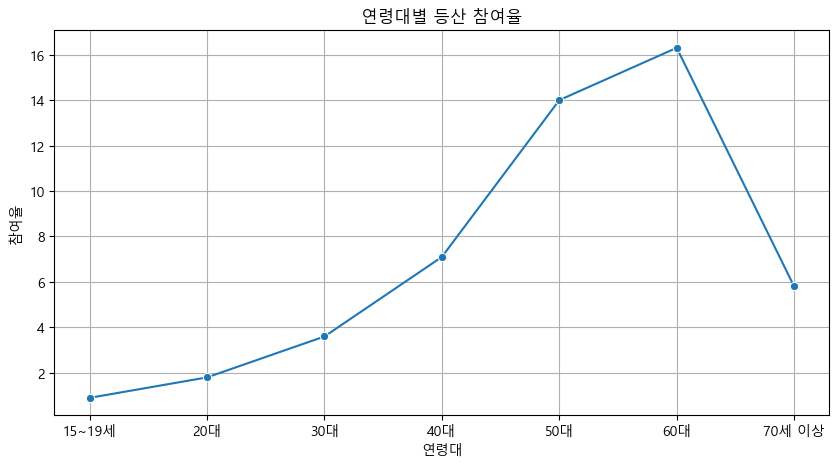

In [12]:
#@title Q1: 사람들이 나이가 들면서 점점 등산을 선호하는가?

# 연령대 행만 선택
age_rows = [
    '연령별_15~19세',
    '연령별_20대',
    '연령별_30대',
    '연령별_40대',
    '연령별_50대',
    '연령별_60대',
    '연령별_70세이상'
]

# 등산 데이터 추출
mountain_data = df_weekend.loc[age_rows, '등산']

# 시각화용 DataFrame 생성
plot_df = pd.DataFrame({
    '연령대': [
        '15~19세',
        '20대',
        '30대',
        '40대',
        '50대',
        '60대',
        '70세 이상'
    ],
    '등산 참여율': mountain_data.values
})

# 그래프
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=plot_df,
    x='연령대',
    y='등산 참여율',
    marker='o'
)

plt.title('연령대별 등산 참여율')
plt.ylabel('참여율')
plt.grid(True)

plt.show()


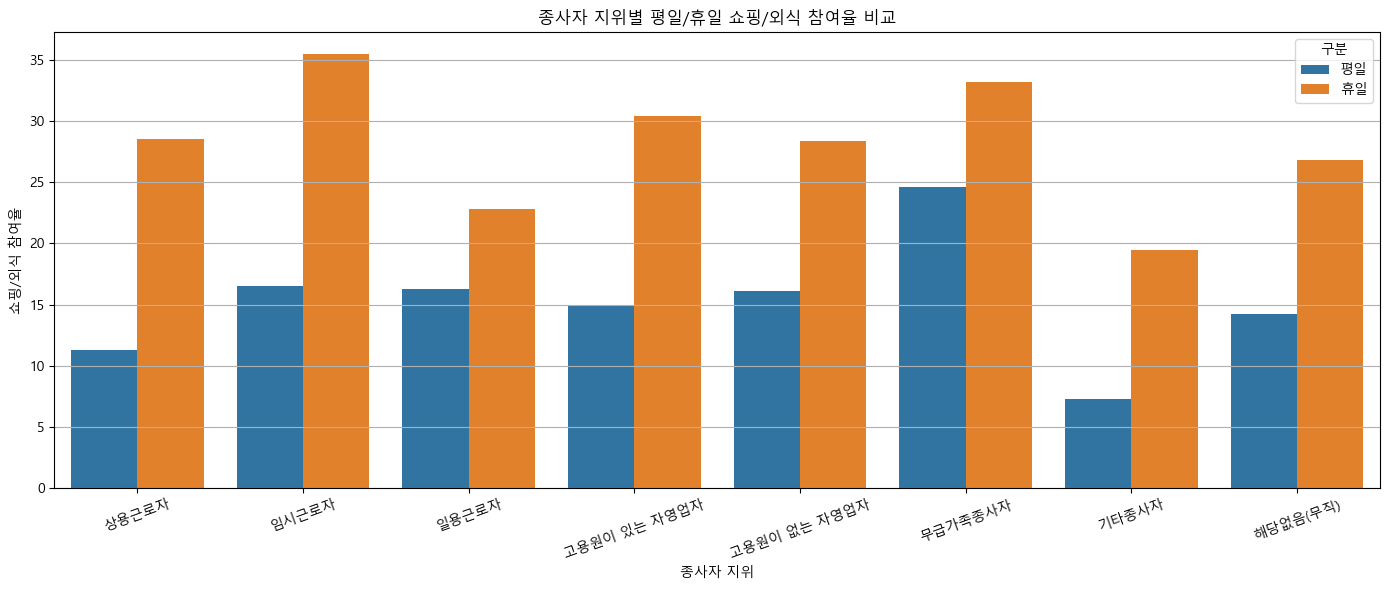

In [ ]:
#@title Q2: 사람들이 주중보다 주말에 외식을 자주하는가?
# 외식 데이터 추출
job_rows = [
    idx for idx in df_weekday.index
    if '종사자지위별' in idx
]


plot_data = []

for row in job_rows:

    # 보기 좋게 이름 정리
    label = row.replace('종사자지위별_', '')

    # 평일 쇼핑/외식 참여율
    weekday_value = pd.to_numeric(
        df_weekday.loc[row, '쇼핑/외식'],
        errors='coerce'
    )

    # 휴일 쇼핑/외식 참여율
    weekend_value = pd.to_numeric(
        df_weekend.loc[row, '쇼핑/외식'],
        errors='coerce'
    )

    # 평일 데이터 추가
    plot_data.append({
        '종사자 지위': label,
        '구분': '평일',
        '쇼핑/외식 참여율': weekday_value
    })

    # 휴일 데이터 추가
    plot_data.append({
        '종사자 지위': label,
        '구분': '휴일',
        '쇼핑/외식 참여율': weekend_value
    })

# DataFrame 생성
plot_df = pd.DataFrame(plot_data)


plt.figure(figsize=(14, 6))

sns.barplot(
    data=plot_df,
    x='종사자 지위',
    y='쇼핑/외식 참여율',
    hue='구분'
)

# 제목
plt.title('종사자 지위별 평일/휴일 쇼핑/외식 참여율 비교')

# x축 글자 회전
plt.xticks(rotation=20)

# y축 격자
plt.grid(axis='y')

# 여백 자동 조정
plt.tight_layout()

# 출력
plt.show()

  결혼 상태         활동 종류        참여율
0    미혼   홈페이지/블로그 관리   0.600000
1    미혼  인터넷 검색/ 영상편집  25.000000
2    미혼            게임  26.400000
3    미혼         전체 평균  17.333333
4    기혼   홈페이지/블로그 관리   0.200000
5    기혼  인터넷 검색/ 영상편집  22.000000
6    기혼            게임   5.300000
7    기혼         전체 평균   9.166667


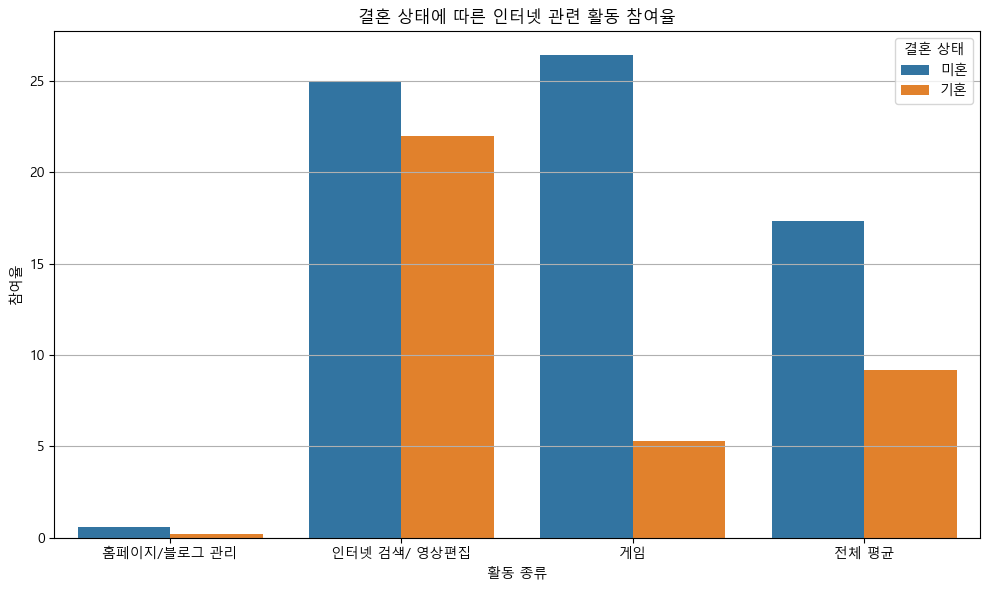

In [21]:
#@title Q3: 결혼 여부가 인터넷 사용비율에 영향을 미치는가?

internet_columns = [
    '홈페이지/블로그 관리',
    '인터넷 검색/ 영상편집',
    '게임'
]

marriage_rows = [
    '혼인상태별_미혼',
    '혼인상태별_기혼'
]

plot_data = []

for marriage in marriage_rows:

    # 보기 좋은 이름
    marriage_label = marriage.replace('혼인상태별_', '')

    values = []

    for activity in internet_columns:

        # 값 추출
        value = pd.to_numeric(
            df_weekday.loc[marriage, activity],
            errors='coerce'
        )

        values.append(value)

        # 활동별 데이터 추가
        plot_data.append({
            '결혼 상태': marriage_label,
            '활동 종류': activity,
            '참여율': value
        })


    total_mean = sum(values) / len(values)

    plot_data.append({
        '결혼 상태': marriage_label,
        '활동 종류': '전체 평균',
        '참여율': total_mean
    })

plot_df = pd.DataFrame(plot_data)

print(plot_df)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x='활동 종류',
    y='참여율',
    hue='결혼 상태'
)

# 제목
plt.title('결혼 상태에 따른 인터넷 관련 활동 참여율')

# y축 격자
plt.grid(axis='y')

# 여백 자동 조정
plt.tight_layout()

# 출력
plt.show()